# TOPOTEX Pipeline Playground

**自己的 GLB → 完整 pipeline 每一步可视、可调、可导出。**

用法：把带纹理的 `.glb` 放进 `workspace/`（要求与数据集门禁一致：
三角网格、单张 baseColor 纹理、顶点 UV 在 [0,1]），然后从上到下运行。
每一步的产物都落在 `workspace/outputs/<资产名>/`。

```
GLB (mesh + texture)
  → DIY 参考图（自选相机角度）
  → 六个标准视角条件图
  → Face Set Latent Z_F（PCA 染色烘焙成纹理 → zf_pca.glb）
  → Global UV Query（canonical layout）
  → rectified flow 生成过程（Euler 轨迹逐步可视）
  → 最终新纹理 → pred.glb / gt.glb
```

说明：模型消费的条件是**六视角图**；本 notebook 用资产自身纹理渲染
六视图（与生成式六视图已验证条件等效）。"任意参考图 + 无纹理 mesh"
需要 UniTEX 重新生成六视图，待 GPU 空闲后作为可选路径加入。

In [1]:
# ---- 交互参数（改完从这个 cell 起重跑）---------------------------------
GLB_NAME = None       # workspace/ 里的文件名或序号（如 "chair.glb" / 0）；
                      # None = 最近放入（按修改时间）的那个
REF_AZ, REF_EL = 30.0, 20.0   # DIY 参考图相机角度（方位角 / 仰角，度）
SEED = 20260727       # 生成种子（换种子 = 同条件下另一次采样）
STEPS = 50            # Euler ODE 步数
CKPT_PATH = None      # None = checkpoints/baseline；或 "runs/<name>"

import json
import sys
import types
from pathlib import Path

import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

# CJK font for plot titles (otherwise every Chinese glyph warns + renders
# as a box); harmless beta-API notice from the topology transformer muted
from matplotlib import font_manager as _fm
_cjk = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if _cjk.exists():
    _fm.fontManager.addfont(str(_cjk))
    _fams = sorted({f.name for f in _fm.fontManager.ttflist
                    if "CJK" in f.name})
    matplotlib.rcParams["font.sans-serif"] = (
        _fams + matplotlib.rcParams["font.sans-serif"])
    matplotlib.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message=".*index_reduce.*")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from topotex.data.builder import extract_glb, uv_address
from topotex.data.builder import bake_gt
from topotex.data.mesh import (CANONICAL_VIEWS, camera_matrices,
                               dilate_texture, linear_to_srgb_u8,
                               rasterize_view, render_albedo_rebake)
from topotex.layers.topology import build_face_graph
from topotex.models import MaskedFlowMatching
from topotex import build_models

# 共享机上其它任务可能占卡——自动选剩余显存最多的 GPU
if torch.cuda.is_available():
    free = [torch.cuda.mem_get_info(i)[0]
            for i in range(torch.cuda.device_count())]
    DEVICE = f"cuda:{int(np.argmax(free))}"
    print(f"DEVICE = {DEVICE} (free {max(free) / 2**30:.0f} GiB)")
else:
    DEVICE = "cpu"
WORKSPACE = PROJECT_ROOT / "workspace"
WORKSPACE.mkdir(exist_ok=True)

glbs = sorted((p for p in WORKSPACE.iterdir()
               if p.suffix.lower() in (".glb", ".gltf")),
              key=lambda p: p.stat().st_mtime, reverse=True)
print("workspace/ 中的资产（按修改时间，新的在前）：")
for i, p in enumerate(glbs):
    print(f"  [{i}] {p.name}  ({p.stat().st_size / 1e6:.1f} MB)")
HAVE = False
glb_path = None
if isinstance(GLB_NAME, int):
    if 0 <= GLB_NAME < len(glbs):
        glb_path = glbs[GLB_NAME]
    else:
        print(f"!! 序号 {GLB_NAME} 超出范围（共 {len(glbs)} 个）")
elif GLB_NAME:
    glb_path = WORKSPACE / GLB_NAME
    if not glb_path.exists():
        print(f"!! workspace/{GLB_NAME} 不存在——可用文件见上表")
        glb_path = None
elif glbs:
    glb_path = glbs[0]          # 最近放入的
else:
    mf = PROJECT_ROOT / "output" / "source_manifests" / "glbs.jsonl"
    if mf.exists():
        cand = Path(json.loads(open(mf).readline())["glb_path"])
        if cand.exists():
            print(f"  （空，使用演示资产 {cand.name}）")
            glb_path = cand
    if glb_path is None:
        print("  （空）把带纹理的 .glb 放进 workspace/ 后重跑本 cell")

if glb_path is not None:
    # 与数据集构建完全相同的门禁：三角面 + 单 baseColor 纹理 + 顶点 UV [0,1]
    from topotex.data.builder import SkipSample
    try:
        try:
            V, F, UV, TEX = extract_glb(glb_path)
        except SkipSample as e:
            if "uv outside" not in str(e):
                raise
            # 轻微 UV 越界（常见于边界处 wrap 一点点）——playground 容忍
            # 到 0.1 并截断；数据集门禁保持严格
            V, F, UV, TEX = extract_glb(glb_path, uv_tol=0.1)
            print("注意：UV 略超 [0,1]，已截断（数据集门禁会拒绝该资产）")
        HAVE = True
    except SkipSample as e:
        print(f"!! {glb_path.name} 未通过数据门禁：{e}\n"
              "   要求：三角网格、单张 baseColor 纹理、顶点 UV 在 [0,1]"
              "（无平铺/重叠）")
    except Exception as e:
        print(f"!! {glb_path.name} 无法解析：{type(e).__name__}: {e}")

if HAVE and not (( (PROJECT_ROOT / CKPT_PATH) if CKPT_PATH
                  else PROJECT_ROOT / "checkpoints" / "baseline")
                 / "ckpt.pt").exists():
    print("!! 找不到 checkpoint（ckpt.pt）——检查 CKPT_PATH")
    HAVE = False

if HAVE:
    V64, F64 = V.astype(np.float64), F.astype(np.int64)
    out_dir = WORKSPACE / "outputs" / glb_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"\n选中: {glb_path.name} | faces {len(F)} | verts {len(V)} "
          f"| texture {TEX.shape[1]}x{TEX.shape[0]}")
    print("输出目录:", out_dir)

    RUN = (PROJECT_ROOT / CKPT_PATH) if CKPT_PATH \
        else PROJECT_ROOT / "checkpoints" / "baseline"
    from topotex import TopoTexPipeline
    pipe = TopoTexPipeline.from_checkpoint(RUN, DEVICE)
    ck = pipe.checkpoint
    conditioner, dit, fm = (pipe.model.conditioner, pipe.model.dit,
                            pipe.model.schedule)
    print(f"checkpoint: {RUN.name} | step {ck.get('global_step')} | "
          f"seed {SEED} | steps {STEPS}")

    def render_view(tex_u8, az, el, res=512, bg=235):
        cn = types.SimpleNamespace(vertices=V64, faces=F64)
        ur = types.SimpleNamespace(uv_vertices=UV.astype(np.float64),
                                   uv_faces=F64,
                                   uv_face_to_mesh_face=np.arange(len(F64)))
        gb = rasterize_view(V64, F64,
                            camera_matrices(az, el, V64.min(0), V64.max(0)),
                            res)
        img = linear_to_srgb_u8(render_albedo_rebake(cn, ur, tex_u8, gb))
        img[~gb["mask"]] = bg
        return img, gb["mask"]

    def export_textured_glb(path, tex):
        import trimesh
        from PIL import Image
        mat = trimesh.visual.material.PBRMaterial(
            baseColorTexture=Image.fromarray(tex),
            metallicFactor=0.0, roughnessFactor=1.0)
        uvg = UV.astype(np.float64).copy()
        uvg[:, 1] = 1.0 - uvg[:, 1]     # 行序 -> GLB v-up（ingest 的逆）
        tm = trimesh.Trimesh(V64, F64, process=False,
                             visual=trimesh.visual.TextureVisuals(
                                 uv=uvg, material=mat))
        tm.export(path)
        print("GLB -> %s (%.2f MB)" % (path, Path(path).stat().st_size / 1e6))
        return Path(path)
if not HAVE:
    print("HAVE = False — 后续 cell 会跳过")

DEVICE = cuda:0 (free 48 GiB)
workspace/ 中的资产（按修改时间，新的在前）：
  [0] spot.glb  (0.2 MB)


注意：UV 略超 [0,1]，已截断（数据集门禁会拒绝该资产）

选中: spot.glb | faces 5856 | verts 3225 | texture 1024x1024
输出目录: /root/youjiaZhang/TopoTex-refactor/workspace/outputs/spot


08:26:49 INFO topotex.pipelines.inference | loaded checkpoint /root/youjiaZhang/TopoTex-refactor/checkpoints/baseline (step 123875, generator fm)


checkpoint: baseline | step 123875 | seed 20260727 | steps 50


## Step 1 — DIY 参考图（改 `REF_AZ` / `REF_EL` 换角度）

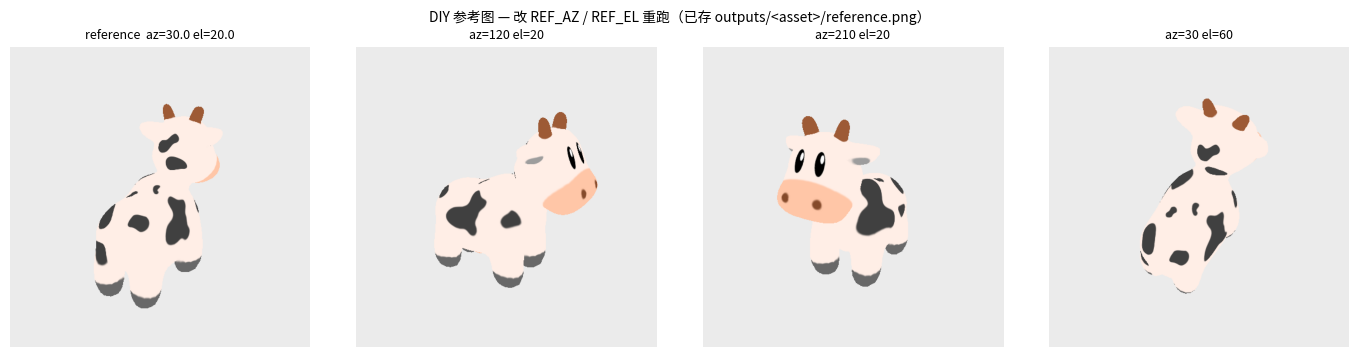

In [2]:
if HAVE:
    from PIL import Image
    ref_img, _ = render_view(TEX, REF_AZ, REF_EL)
    Image.fromarray(ref_img).save(out_dir / "reference.png")
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
    axes[0].imshow(ref_img)
    axes[0].set_title(f"reference  az={REF_AZ} el={REF_EL}", fontsize=9)
    for i, (az2, el2) in enumerate(((REF_AZ + 90, REF_EL),
                                    (REF_AZ + 180, REF_EL),
                                    (REF_AZ, REF_EL + 40))):
        im2, _ = render_view(TEX, az2, el2)
        axes[i + 1].imshow(im2)
        axes[i + 1].set_title(f"az={az2:g} el={el2:g}", fontsize=9)
    for a in axes: a.axis("off")
    plt.suptitle("DIY 参考图 — 改 REF_AZ / REF_EL 重跑（已存 "
                 "outputs/<asset>/reference.png）", fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("no input")

## Step 2 — 六个标准视角条件图

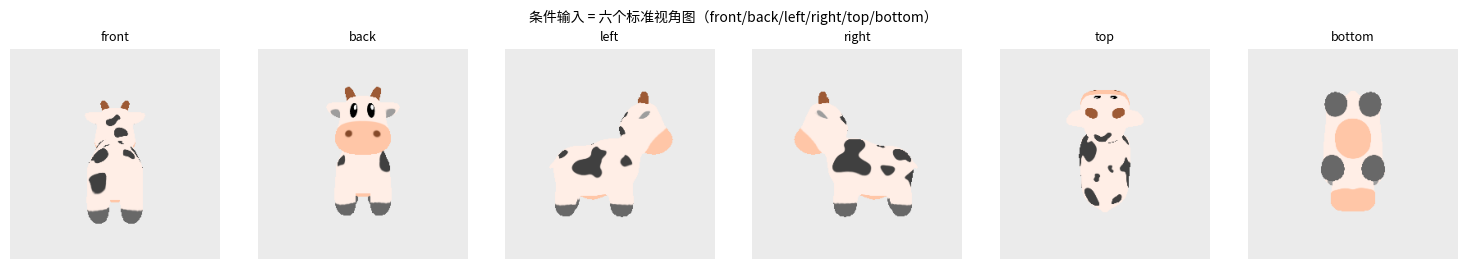

In [3]:
if HAVE:
    views = []
    for vi in range(6):
        _, az2, el2 = CANONICAL_VIEWS[vi]
        im2, _ = render_view(TEX, az2, el2, res=256)
        views.append(im2)
    mv = torch.tensor(np.stack(views).transpose(0, 3, 1, 2), device=DEVICE)
    fig, axes = plt.subplots(1, 6, figsize=(15, 2.7))
    for vi in range(6):
        axes[vi].imshow(views[vi])
        axes[vi].set_title(CANONICAL_VIEWS[vi][0], fontsize=9)
        axes[vi].axis("off")
    plt.suptitle("条件输入 = 六个标准视角图（front/back/left/right/top/"
                 "bottom）", fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("no input")

## Step 3 — Face Set Latent `Z_F`（每三角形一个 token）

PCA 前三主成分作 RGB，烘焙进 canonical UV 并导出 `zf_pca.glb` — 直接在查看器里看 latent 的部件结构。

Z_F: (5856, 256) — 每个三角形一个 token


GLB -> /root/youjiaZhang/TopoTex-refactor/workspace/outputs/spot/zf_pca.glb (0.19 MB)


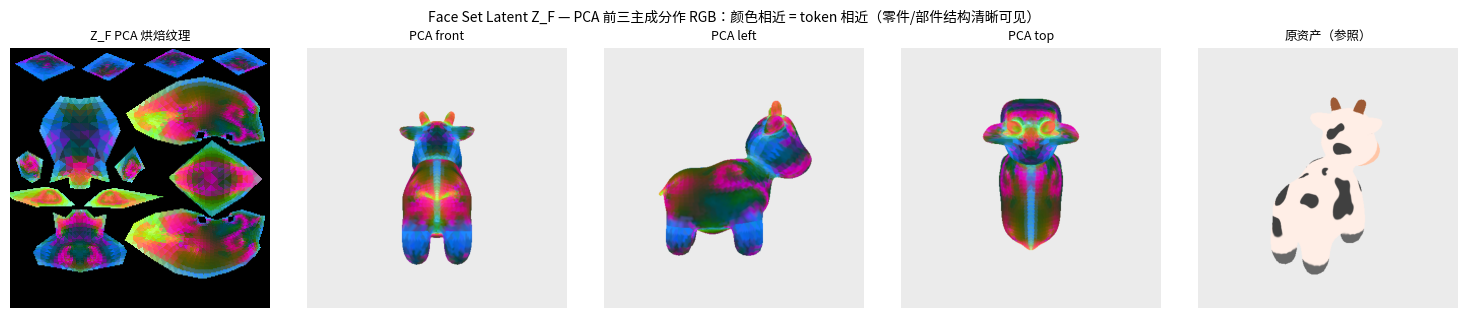

In [4]:
if HAVE:
    graph = build_face_graph(torch.tensor(V, device=DEVICE),
                             torch.tensor(F64, device=DEVICE))
    meshd = {"vertices": torch.tensor(V, device=DEVICE),
             "faces": torch.tensor(F64, device=DEVICE)}
    with torch.no_grad():
        Z_F, _ = conditioner.encode_faces(meshd, mv.float()[None] / 255,
                                          graph)
    zf = Z_F[0].float().cpu().numpy() if Z_F.dim() == 3 \
        else Z_F.float().cpu().numpy()
    print("Z_F:", tuple(zf.shape), "— 每个三角形一个 token")
    z0 = zf - zf.mean(0)
    _, _, vt = np.linalg.svd(z0, full_matrices=False)
    pc = z0 @ vt[:3].T
    if pc.shape[1] < 3:   # tiny meshes: fewer than 3 components
        pc = np.pad(pc, ((0, 0), (0, 3 - pc.shape[1])))
    lo, hi = np.percentile(pc, 2, axis=0), np.percentile(pc, 98, axis=0)
    colors = np.clip((pc - lo) / np.maximum(hi - lo, 1e-9), 0, 1)

    # 把逐面 PCA 颜色烘焙进 canonical UV -> 纹理 -> GLB
    fid0, bary0, val0 = uv_address(UV, F)
    vb = val0.astype(bool)
    tex_pca = np.zeros((256, 256, 3), np.uint8)
    tex_pca[vb] = (colors[fid0[vb]] * 255).astype(np.uint8)
    tex_pca_d = dilate_texture(tex_pca.copy(), vb)
    export_textured_glb(out_dir / "zf_pca.glb", tex_pca_d)

    fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
    axes[0].imshow(tex_pca)
    axes[0].set_title("Z_F PCA 烘焙纹理", fontsize=9)
    for i, vi in enumerate((0, 2, 4)):
        _, az2, el2 = CANONICAL_VIEWS[vi]
        im2, _ = render_view(tex_pca_d, az2, el2)
        axes[i + 1].imshow(im2)
        axes[i + 1].set_title("PCA " + CANONICAL_VIEWS[vi][0], fontsize=9)
    im2, _ = render_view(TEX, REF_AZ, REF_EL)
    axes[4].imshow(im2); axes[4].set_title("原资产（参照）", fontsize=9)
    for a in axes: a.axis("off")
    plt.suptitle("Face Set Latent Z_F — PCA 前三主成分作 RGB：颜色相近 = "
                 "token 相近（零件/部件结构清晰可见）", fontsize=10)
    plt.tight_layout(); plt.show()
else:
    print("no input")

## Step 4 — 纹理生成过程（rectified flow Euler 轨迹）

改 `SEED` 得到同条件下的另一次采样；改 `STEPS` 看步数影响。

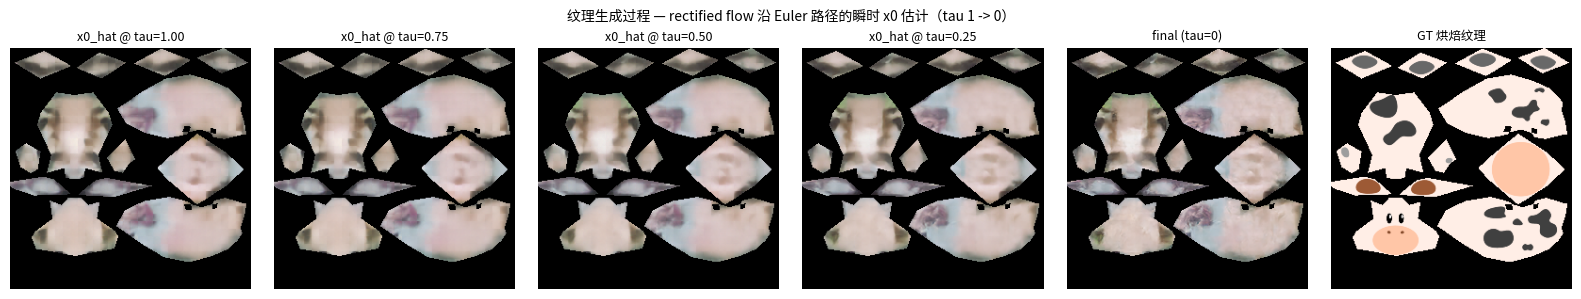

canonical UV PSNR vs GT: 9.35 dB


In [5]:
if HAVE:
    gt_canon = bake_gt(fid0, bary0, val0, UV.astype(np.float64), F64, TEX)
    q = {"face_id": torch.tensor(fid0.astype(np.int64), device=DEVICE),
         "barycentric": torch.tensor(bary0.astype(np.float32),
                                     device=DEVICE),
         "valid_mask": torch.tensor(vb, device=DEVICE)}
    with torch.no_grad():
        o = conditioner(meshd, None,
                        {"face_id": q["face_id"],
                         "barycentric": q["barycentric"].permute(1, 2, 0)},
                        face_tokens=Z_F)
        cond_uv = o["uv_condition"]
        m1 = q["valid_mask"].float()[None, None]
        gg = torch.Generator(device=DEVICE).manual_seed(SEED)
        x = torch.randn(1, 3, 256, 256, device=DEVICE, generator=gg) * m1
        taus = torch.linspace(1.0, 0.0, STEPS + 1, device=DEVICE)
        snaps, SNAP_TAUS = {}, (1.0, 0.75, 0.5, 0.25)
        for i in range(STEPS):
            t_int = (taus[i] * fm.T).round().clamp(min=1).long()
            v = dit(x, cond_uv, m1, t_int.expand(1))
            x0_hat = (x - taus[i] * v).clamp(-1, 1)
            for tv in SNAP_TAUS:
                if tv not in snaps and float(taus[i]) <= tv + 1e-9:
                    snaps[tv] = x0_hat[0].clone()
            x = (x - (taus[i] - taus[i + 1]) * v) * m1

    def to_im(tt):
        im2 = ((tt.clamp(-1, 1) + 1) / 2 * 255).round().byte()
        im2 = im2.permute(1, 2, 0).cpu().numpy().copy()
        im2[~vb] = 0
        return im2

    pred = to_im(x[0])
    fig, axes = plt.subplots(1, 6, figsize=(16, 3.0))
    for c, tv in enumerate(SNAP_TAUS):
        axes[c].imshow(to_im(snaps[tv]))
        axes[c].set_title("x0_hat @ tau=%.2f" % tv, fontsize=9)
    axes[4].imshow(pred); axes[4].set_title("final (tau=0)", fontsize=9)
    axes[5].imshow(gt_canon); axes[5].set_title("GT 烘焙纹理", fontsize=9)
    for a in axes: a.axis("off")
    plt.suptitle("纹理生成过程 — rectified flow 沿 Euler 路径的瞬时 x0 "
                 "估计（tau 1 -> 0）", fontsize=10)
    plt.tight_layout(); plt.show()
    mse = float(((gt_canon[vb] / 255. - pred[vb] / 255.) ** 2).mean())
    print("canonical UV PSNR vs GT: %.2f dB" % (10 * np.log10(
        1 / max(mse, 1e-12))))
    if glb_path.parent != WORKSPACE:
        print("（演示资产不在训练集时属 zero-shot——2K 基线的未见 mesh "
              "水平约 11 dB，10K 训练的目标轴之一）")
else:
    print("no input")

## Step 5 — 最终新纹理 GLB（pred vs GT 实体渲染 + 导出清单）

GLB -> /root/youjiaZhang/TopoTex-refactor/workspace/outputs/spot/pred.glb (0.21 MB)
GLB -> /root/youjiaZhang/TopoTex-refactor/workspace/outputs/spot/gt.glb (0.15 MB)


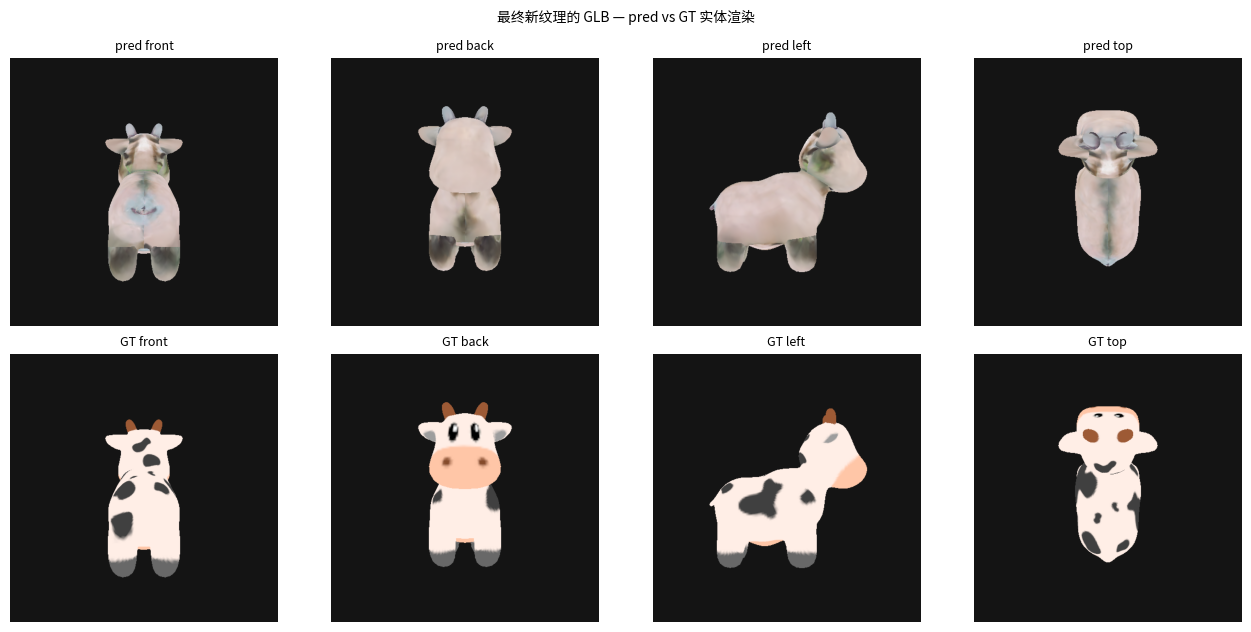


本次输出（可直接下载/在查看器打开）：
  workspace/outputs/spot/gt.glb  (0.15 MB)
  workspace/outputs/spot/pred.glb  (0.21 MB)
  workspace/outputs/spot/reference.png  (0.01 MB)
  workspace/outputs/spot/zf_pca.glb  (0.19 MB)


In [6]:
if HAVE:
    pred_d = dilate_texture(pred.copy(), vb)
    gt_d = dilate_texture(gt_canon.copy(), vb)
    p_pred = export_textured_glb(out_dir / "pred.glb", pred_d)
    export_textured_glb(out_dir / "gt.glb", gt_d)

    fig, axes = plt.subplots(2, 4, figsize=(13, 6.4))
    for c, vi in enumerate((0, 1, 2, 4)):
        _, az2, el2 = CANONICAL_VIEWS[vi]
        ia, _ = render_view(pred_d, az2, el2, bg=20)
        ib, _ = render_view(gt_d, az2, el2, bg=20)
        axes[0][c].imshow(ia)
        axes[0][c].set_title("pred " + CANONICAL_VIEWS[vi][0], fontsize=9)
        axes[1][c].imshow(ib)
        axes[1][c].set_title("GT " + CANONICAL_VIEWS[vi][0], fontsize=9)
    for a in axes.ravel(): a.axis("off")
    plt.suptitle("最终新纹理的 GLB — pred vs GT 实体渲染", fontsize=10)
    plt.tight_layout(); plt.show()

    print("\n本次输出（可直接下载/在查看器打开）：")
    for p in sorted(out_dir.iterdir()):
        print(f"  {p.relative_to(PROJECT_ROOT)}  "
              f"({p.stat().st_size / 1e6:.2f} MB)")
else:
    print("no input")